Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/train_mobile_clasification.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


ambil fitur dan target

In [8]:
X = df[['ram', 'battery_power']].values
y = df['price_range'].values

normalisasi data


In [9]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

One-hot Encoding

In [10]:
import numpy as np

num_classes = 4
y_onehot = np.eye(num_classes)[y]

Fungsi Softmax

In [11]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # stabil
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Cross Entropy Loss

In [12]:
def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

Inisialisasi Parameter

In [13]:
np.random.seed(42)

n_features = X.shape[1]
n_classes = 4

W = np.random.randn(n_features, n_classes)
b = np.zeros((1, n_classes))

Training (SGD)

In [14]:
learning_rate = 0.01
epochs = 200

loss_history = []

for epoch in range(epochs):
    # Forward
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    # Loss
    loss = cross_entropy(y_onehot, y_pred)
    loss_history.append(loss)

    # Gradient
    m = X.shape[0]
    dz = (y_pred - y_onehot) / m
    dW = np.dot(X.T, dz)
    db = np.sum(dz, axis=0, keepdims=True)

    # Update
    W -= learning_rate * dW
    b -= learning_rate * db

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 1.3174
Epoch 20, Loss: 1.2793
Epoch 40, Loss: 1.2442
Epoch 60, Loss: 1.2118
Epoch 80, Loss: 1.1821
Epoch 100, Loss: 1.1547
Epoch 120, Loss: 1.1294
Epoch 140, Loss: 1.1061
Epoch 160, Loss: 1.0847
Epoch 180, Loss: 1.0648


Plot Loss

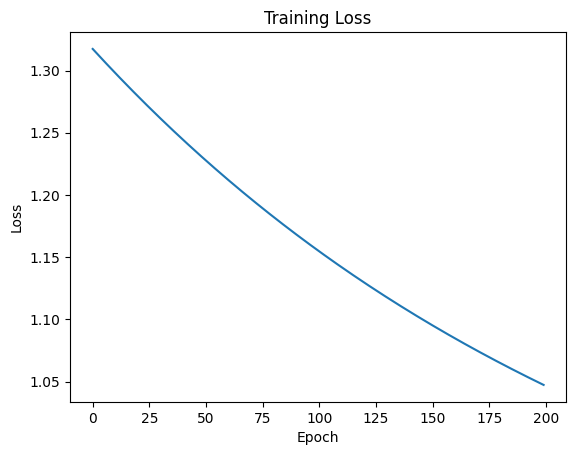

In [15]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Decision Boundary

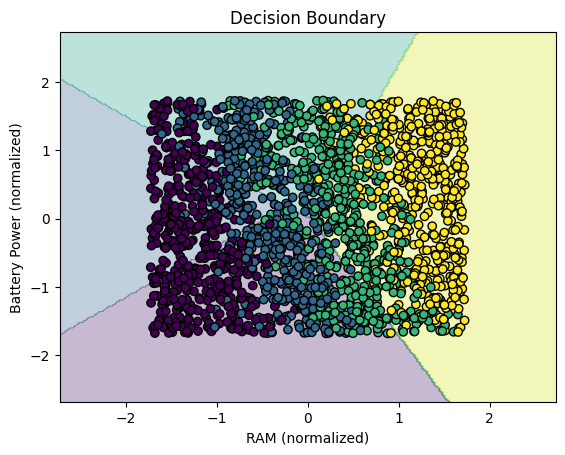

In [16]:
# Grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Prediksi
z = np.dot(grid, W) + b
probs = softmax(z)
preds = np.argmax(probs, axis=1)

Z = preds.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlabel("RAM (normalized)")
plt.ylabel("Battery Power (normalized)")
plt.title("Decision Boundary")
plt.show()

Hitung Akurasi

In [17]:
z = np.dot(X, W) + b
y_pred = np.argmax(softmax(z), axis=1)

accuracy = np.mean(y_pred == y)
print("Accuracy:", accuracy)

Accuracy: 0.461
